Linear Regression Calculator
Enter your data points separated by spaces (e.g., 1 2 3 4 5)
Enter x values: 1 2 3 4
Enter y values: 2 3 5 4

--- Results ---
Slope (m): 0.8000
Intercept (c): 1.5000
Equation: y = 0.8000x + 1.5000
MAE: 0.5500
MSE: 0.4500
RMSE: 0.6708
R^2: 0.6400

Plot saved as 'regression_and_evaluation.png'. Opening plot window...


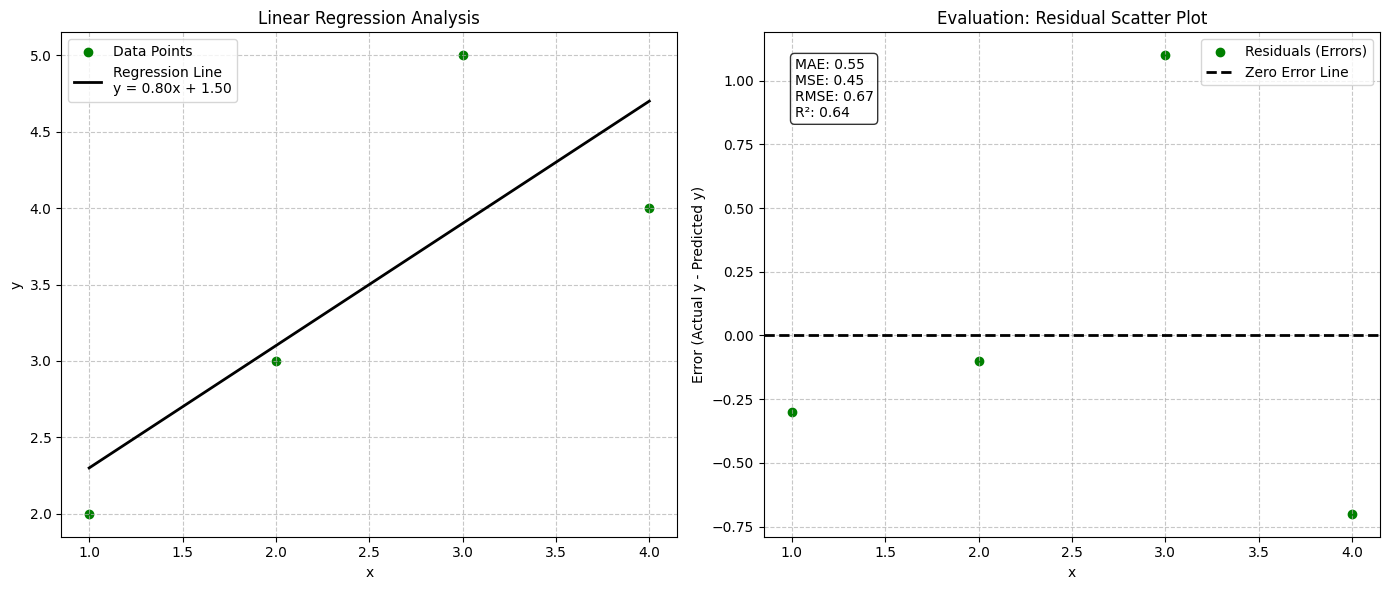

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- User Input Section ---
print("Linear Regression Calculator")
print("Enter your data points separated by spaces (e.g., 1 2 3 4 5)")

# Get input strings
x_input = input("Enter x values: ")
y_input = input("Enter y values: ")

# Convert input strings to numpy arrays of floats
try:
    x = np.array([float(i) for i in x_input.split()])
    y = np.array([float(i) for i in y_input.split()])
except ValueError:
    print("Error: Please enter only numbers separated by spaces.")
    exit()

# Validate input length and empty arrays
if len(x) == 0 or len(y) == 0:
    print("Error: No data provided.")
    exit()

if len(x) != len(y):
    print(f"Error: Mismatched data. You entered {len(x)} x-values and {len(y)} y-values.")
    exit()

n = len(x)

# --- Calculations Section ---
# Calculating sums
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x_sq = np.sum(x**2)

# Calculating m (slope) and c (intercept)
denominator = (n * sum_x_sq - sum_x**2)

if denominator == 0:
    print("Error: Cannot calculate regression line. All x values are identical.")
    exit()

m = (n * sum_xy - sum_x * sum_y) / denominator
c = (sum_y - m * sum_x) / n

# Regression line equation
y_pred = m * x + c

# Calculate Errors
mae = np.mean(np.abs(y - y_pred)) # Mean Absolute Error
mse = np.mean((y - y_pred)**2)    # Mean Squared Error
rmse = np.sqrt(mse)               # Root Mean Squared Error

# R^2: Coefficient of Determination
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

if ss_tot == 0:
    r2 = 1.0 # Perfect fit if all y values are exactly the same
else:
    r2 = 1 - (ss_res / ss_tot)

# Calculate Residuals for the Scatter Plot
residuals = y - y_pred

# --- Output Results to Console ---
print("\n--- Results ---")
print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")
print(f"Equation: y = {m:.4f}x + {c:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

# --- Plotting Section ---
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Plot the Regression Line on the first subplot
ax1.scatter(x, y, color='green', label='Data Points')
ax1.plot(x, y_pred, color='black', linewidth=2, label=f'Regression Line\ny = {m:.2f}x + {c:.2f}')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Linear Regression Analysis')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Plot the Evaluation Metrics as a Residual Scatter Plot
ax2.scatter(x, residuals, color='green', label='Residuals (Errors)')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Zero Error Line')

# Add text annotations of the overall metrics directly onto the scatter plot
metrics_text = f"MAE: {mae:.2f}\nMSE: {mse:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.2f}"
ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('x')
ax2.set_ylabel('Error (Actual y - Predicted y)')
ax2.set_title('Evaluation: Residual Scatter Plot')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Ensure layout isn't cramped
plt.tight_layout()

# Save and show plot
plt.savefig('regression_and_evaluation.png')
print("\nPlot saved as 'regression_and_evaluation.png'. Opening plot window...")
plt.show()